# Week 10 - ARIA v70

## Analysis and application of Remote sensing & geospatial information

In [4]:
import os
from dotenv import load_dotenv
import pystac_client
import planetary_computer as pc
import stackstac
import numpy as np
import matplotlib.pyplot as plt

# 載入 .env 檔案
load_dotenv()

# 從環境變數讀取 BBOX 並轉換為浮點數列表
BBOX_WEST = float(os.getenv('BBOX_WEST'))
BBOX_SOUTH = float(os.getenv('BBOX_SOUTH'))
BBOX_EAST = float(os.getenv('BBOX_EAST'))
BBOX_NORTH = float(os.getenv('BBOX_NORTH'))
HUALIEN_BBOX = [BBOX_WEST, BBOX_SOUTH, BBOX_EAST, BBOX_NORTH]

# 讀取時間範圍
PRE_DATE_RANGE = os.getenv('PRE_DATE_RANGE')
POST_DATE_RANGE = os.getenv('POST_DATE_RANGE')

print("BBOX:", HUALIEN_BBOX)
print("災前觀測期:", PRE_DATE_RANGE)
print("災後觀測期:", POST_DATE_RANGE)

BBOX: [121.2574, 23.6546, 121.4984, 23.7447]
災前觀測期: 2025-10-01/2025-11-05
災後觀測期: 2025-11-12/2025-11-30


Captain's Log 1: 初始化與資料搜尋
目的： 透過 Planetary Computer STAC API 搜尋災後 (2025-11-12 至 2025-11-30) 覆蓋花蓮馬太鞍溪區域的 Sentinel-1 RTC 雷達影像。
預期結果： 列出符合條件的場景清單，並確認其軌道方向 (Orbit Direction)，以便後續挑選災前/災後一致的影像。

In [5]:
# 建立與 Planetary Computer 的連線
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=pc.sign_inplace,
)

# 1. 搜尋災後影像 (Post-disaster)
search_post = catalog.search(
    collections=['sentinel-1-rtc'],
    bbox=HUALIEN_BBOX,
    datetime=POST_DATE_RANGE,
)
items_post = list(search_post.items())

# 2. 搜尋災前影像 (Pre-disaster)
search_pre = catalog.search(
    collections=['sentinel-1-rtc'],
    bbox=HUALIEN_BBOX,
    datetime=PRE_DATE_RANGE,
)
items_pre = list(search_pre.items())

print(f"總共找到 {len(items_pre)} 筆災前影像，{len(items_post)} 筆災後影像。\n")

# 3. 列出影像資訊，方便我們挑選
print("=== 災後影像清單 (Post) ===")
for item in items_post:
    date = item.datetime.strftime('%Y-%m-%d')
    orbit = item.properties.get('sat:orbit_state')
    print(f"日期: {date} | 軌道: {orbit} | ID: {item.id}")

print("\n=== 災前影像清單 (Pre) ===")
for item in items_pre:
    date = item.datetime.strftime('%Y-%m-%d')
    orbit = item.properties.get('sat:orbit_state')
    print(f"日期: {date} | 軌道: {orbit} | ID: {item.id}")

總共找到 11 筆災前影像，5 筆災後影像。

=== 災後影像清單 (Post) ===
日期: 2025-11-29 | 軌道: ascending | ID: S1A_IW_GRDH_1SDV_20251129T100121_20251129T100146_062091_07C4FB_rtc
日期: 2025-11-25 | 軌道: descending | ID: S1C_IW_GRDH_1SDV_20251125T215150_20251125T215215_005176_00A44D_rtc
日期: 2025-11-23 | 軌道: ascending | ID: S1C_IW_GRDH_1SDV_20251123T100017_20251123T100042_005140_00A313_rtc
日期: 2025-11-19 | 軌道: descending | ID: S1A_IW_GRDH_1SDV_20251119T215250_20251119T215315_061952_07BF82_rtc
日期: 2025-11-13 | 軌道: descending | ID: S1C_IW_GRDH_1SDV_20251113T215150_20251113T215215_005001_009E5E_rtc

=== 災前影像清單 (Pre) ===
日期: 2025-11-05 | 軌道: ascending | ID: S1A_IW_GRDH_1SDV_20251105T100123_20251105T100148_061741_07B75F_rtc
日期: 2025-11-01 | 軌道: descending | ID: S1C_IW_GRDH_1SDV_20251101T215151_20251101T215216_004826_009893_rtc
日期: 2025-10-30 | 軌道: ascending | ID: S1C_IW_GRDH_1SDV_20251030T100018_20251030T100043_004790_00975D_rtc
日期: 2025-10-26 | 軌道: descending | ID: S1A_IW_GRDH_1SDV_20251026T215251_20251026T215316_061602_07

Captain's Log 2: 影像篩選與預處理
目的： 根據 STAC 搜尋結果，選定 11-13 (災後) 與 11-01 (災前) 這兩組相同為 descending 軌道的影像進行分析。將 VV 頻段轉換為 dB 值，並套用 Median Filter 以消除 SAR 特有的斑點雜訊 (Speckle noise)，為後續的閾值設定做準備。
預期結果： 獲得平滑後的 SAR dB 矩陣。

In [6]:
import scipy.ndimage

# 1. 精準挑選我們決定的那兩張影像
post_item = next(item for item in items_post if item.datetime.strftime('%Y-%m-%d') == '2025-11-13')
pre_item = next(item for item in items_pre if item.datetime.strftime('%Y-%m-%d') == '2025-11-01')

print(f"選定的災前影像: {pre_item.id}")
print(f"選定的災後影像: {post_item.id}")

# 2. 透過 stackstac 將 STAC Item 轉為 xarray DataArray (只取 VV 頻段)
# 注意：這裡的解析度設為 10m，並鎖定在我們的 HUALIEN_BBOX
cube = stackstac.stack(
    [pc.sign(pre_item), pc.sign(post_item)],
    assets=['vv'], 
    epsg=32651, # 台灣所在的 UTM 投影區帶 (WGS84 UTM Zone 51N)
    resolution=10, 
    bounds_latlon=HUALIEN_BBOX
)

# 觸發計算，將資料拉到記憶體中 (因為範圍不大，這步應該滿快的)
vv_linear = cube.compute()

# 將災前(0)與災後(1)的資料分開，並去除多餘的維度
vv_pre_linear = vv_linear[0].squeeze().astype(np.float32)
vv_post_linear = vv_linear[1].squeeze().astype(np.float32)

# 3. 將 Linear scale 轉換為 dB (分貝) scale
vv_pre_db = 10 * np.log10(vv_pre_linear.values)
vv_post_db = 10 * np.log10(vv_post_linear.values)

# 4. 斑點雜訊濾波 (Speckle Filtering) - 使用 5x5 的中值濾波器
vv_post_filtered = scipy.ndimage.median_filter(vv_post_db, size=5)
vv_pre_filtered = scipy.ndimage.median_filter(vv_pre_db, size=5)

print("資料讀取與濾波完成！矩陣大小:", vv_post_filtered.shape)

選定的災前影像: S1C_IW_GRDH_1SDV_20251101T215151_20251101T215216_004826_009893_rtc
選定的災後影像: S1C_IW_GRDH_1SDV_20251113T215150_20251113T215215_005001_009E5E_rtc
資料讀取與濾波完成！矩陣大小: (1026, 2470)


Captain's Log 3: 直方圖分析與初步閾值測試
目的： 繪製災後雷達影像的後向散射值 (dB) 直方圖，觀察數值分布。並套用 .env 中設定的 SAR_THRESHOLD (-18 dB) 來生成初步的二元水體遮罩 (Binary Water Mask)，檢視該閾值是否能有效區分水體與陸地。
預期結果： 產出包含直方圖與初步水體遮罩的並排圖表，確認閾值的合理性。

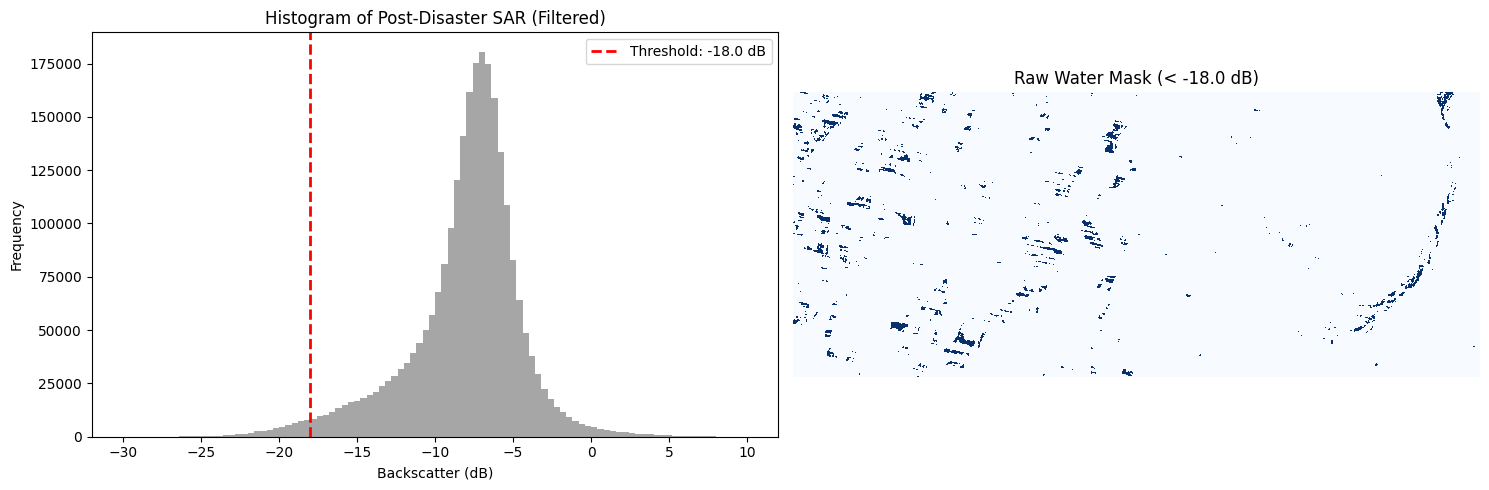

初步偵測到的水體像素數量: 52398


In [10]:
# 從環境變數讀取你設定的閾值，並自動過濾掉 .env 裡的註解
raw_threshold = os.getenv('SAR_THRESHOLD', '-18.0')
# 把字串用 '#' 切開，只取第一部分(數字)，清掉多餘空白後再轉成小數
sar_threshold = float(str(raw_threshold).split('#')[0].strip())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. 繪製直方圖 (Histogram)
# 排除掉可能存在的 NaN (空值) 像素再畫圖
valid_pixels = vv_post_filtered[~np.isnan(vv_post_filtered)]
ax[0].hist(valid_pixels, bins=100, range=(-30, 10), color='gray', alpha=0.7)
ax[0].axvline(sar_threshold, color='red', linestyle='dashed', linewidth=2, 
              label=f'Threshold: {sar_threshold} dB')
ax[0].set_title('Histogram of Post-Disaster SAR (Filtered)')
ax[0].set_xlabel('Backscatter (dB)')
ax[0].set_ylabel('Frequency')
ax[0].legend()

# 2. 預覽閾值效果 (初步的水體遮罩)
raw_water_mask = (vv_post_filtered < sar_threshold) & (~np.isnan(vv_post_filtered))
ax[1].imshow(raw_water_mask, cmap='Blues', interpolation='none')
ax[1].set_title(f'Raw Water Mask (< {sar_threshold} dB)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

print(f"初步偵測到的水體像素數量: {np.sum(raw_water_mask)}")